In [9]:
import numpy as np
import scipy.stats as sp
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Question 1

Use _rejection sampling_ to draw 1000 samples from this distribution.  Show that the samples you've drawn are correctly distributed according to this probability density function.

$p(x) = 0.164\exp{\left(-\frac{(x-10)^4}{2\cdot 8^2}\right)}$

* 1: There are two rejection sampling techniques one for which you reject samples from 

In [5]:
def p(x):
    return 0.164*np.exp(-((x-10)**4)/(2*8**2))

In [6]:
def g(x):
    '''A distribution we can draw samples from'''
    return np.ones_like(x)


x = np.linspace(-50, 50, 1000)
k = .4 #max(p(x) / g(x))

def rejection_sampling(iter=1000):
    samples = []

    for i in range(iter):
        z = np.random.uniform(-50, 50) #random uniform generation of 1000 samples between -50 50 
        u = np.random.uniform(0, k*g(z))

        if u <= p(z): #if 
            samples.append(z)

    return np.array(samples)

In [28]:
s = rejection_sampling(iter=1000000)

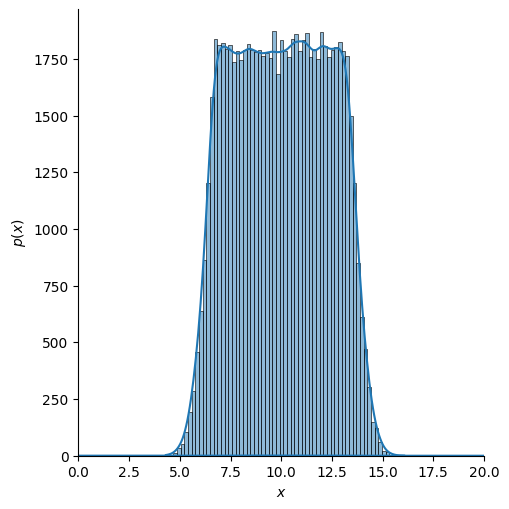

In [29]:
sns.displot(s, kde=True)
plt.plot(x, p(x))
plt.xlim(0, 20)
plt.xlabel('$x$')
plt.ylabel('$p(x)$');

# Question 2
Use _importance sampling_ to estimate the expectation value of $x$, and compare it to the mean of the samples you drew in part 1.

In [30]:
### firstly find the mean of the samples 
np.mean(s)

np.float64(10.002325208989872)

Using the importance sampling formula 
$$
E(h(\theta)|y) = \frac{\frac{1}{S}\sum_{s=1}^S h(\theta^s) w(\theta^s)}{\frac{1}{S}\sum_{s=1}^S w(\theta^s)}
$$

where

$$
w(\theta^s) = \frac{q(\theta^s|y)}{g(\theta^s)}
$$

In [79]:
def q(x):
    return np.exp(-((x-10)**4)/(2*8**2))
μ_g = 12
σ_g = 3 * 6
X_g = sp.distributions.norm(loc=μ_g, scale=σ_g)

S = 1000000
x_gs = X_g.rvs(S)
ws = q(x_gs)/X_g.pdf(x_gs) #formula for the weights above w(theta)

E_x = np.sum(x_gs * ws)/np.sum(ws) #E is just the expectation value of variable X 
print(E_x)

9.999616066327082


We picked a distribution g(x) arbitrarily to draw from. Then, q(x) is our unnormalized p(x) from earlier (coefficient out front removed). We first calculated weights of q(x) with relative to g(x). Then, we want to see how our x-values sampled are averaged given our weighting important.

# Question 3
Calculate the expectation value of $x^2$.


Maybe I have the wrong idea but is it not just... 

In [80]:
E_x = np.sum((x_gs**2) * ws)/np.sum(ws) #E is just the expectation value of variable X 
print(E_x)

103.81842101993946


I can probably check using the reverse with rejection sample ...

In [108]:
np.mean(s**2) ##seems sketchy

np.float64(105.28216682986566)

# Question 4

Revisit the importance sampling example from the Intro to Sampling notebook from class.  There we demonstrated the use of importance sampling to estimate the expectation value of some function of our random variable.  We could also use the weights we computed to probabilistically choose samples from the sampling distribution to keep, in an effort to "reweigh" the sampling distribution to correspond to the target distribution.  Try to implement this, and see if your resampled distribution's histogram matches the target distribution's probability density function.

Professor mentioned that it is sufficient to just explain how this works in regards to what is in the intro_to_sampling notebook.

[ 7.92357919  4.85422432 44.02533003 ... 43.38972881 16.57304374
  1.8111324 ]


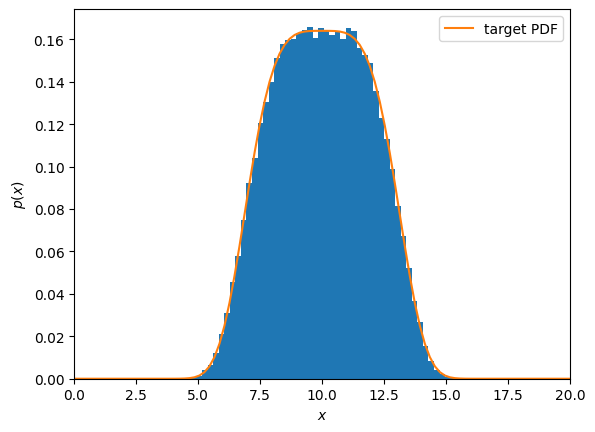

In [126]:
w_max = np.max(ws)
sel = np.random.uniform(0, w_max, S) < ws  # samples of x compared to the pdf by weight 
print(np.random.uniform(0, w_max, S) )
mu = 10
sigma = 2
plt.hist(x_gs[sel], bins=50, density=True);
xs = np.linspace(mu - 5*sigma, mu + 5*sigma, 100)
plt.plot(xs, p(xs), label='target PDF')
plt.legend()
plt.xlim(0, 20)
plt.xlabel('$x$')
plt.ylabel('$p(x)$'); #This is the sample vs the target distribution using the weights. 

This technique involves converting all of our comparisons to a 'weight' space. Firsty, we get S samples between 0 and the weighted maximum. We already have S weights. This works because the weights are proportional to random values of the distribution. You check if you uniform points generated exist below the weight-distribution (similar to rejection sampling where you find if sampled point exist below the PDF). There should be a histogram number of weights (repeated weight counts) for our repeated x_samples. In order words we arbitrarily check whether randomly generated weights exist within our weight-distribution and bin all of the entries that pass. In theory if 'x' sample shows up a lot in the original samples it should have a higher weight, which means "more" randomly sampled weights should 'pass' to the histogram. 